#### ***Technical Support Data Analysis***

***Technical support data can often be a rich source of information on opportunities for improving customer experience. The lesser the trouble customers have with the product the better. Even better when the customers are able to overcome
technical challenge quickly with minimal effort.***

***This notebook analyzes the tech support data and does some basic analysis on problem types, time to resolve the problem and channel of suppor that is most suitable and uses `K-Means Clustering` to group data based on their attribute***

***Dataset Load and Review***

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pylab as plt
%matplotlib inline

import seaborn as sns
from sklearn.model_selection  import train_test_split
from sklearn.cluster import KMeans

from scipy.stats import zscore

#import sklearn.metrics

tech_supp_df = pd.read_csv("data/36_technical_support_data.csv")
tech_supp_df.dtypes

PROBLEM_TYPE              object
no_of_cases                int64
Avg_pending_calls        float64
Avg_resol_time             int64
recurrence_freq          float64
Replace_percent          float64
In_warranty_percent        int64
Post_warranty_percent      int64
dtype: object

***The dataset contains one record for each unique problem type. It has metrics for each type like count, average calls to resolve, average resolution time etc.***

In [2]:
tech_supp_df.shape

(23, 8)

In [3]:
tech_supp_df.head()


,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1


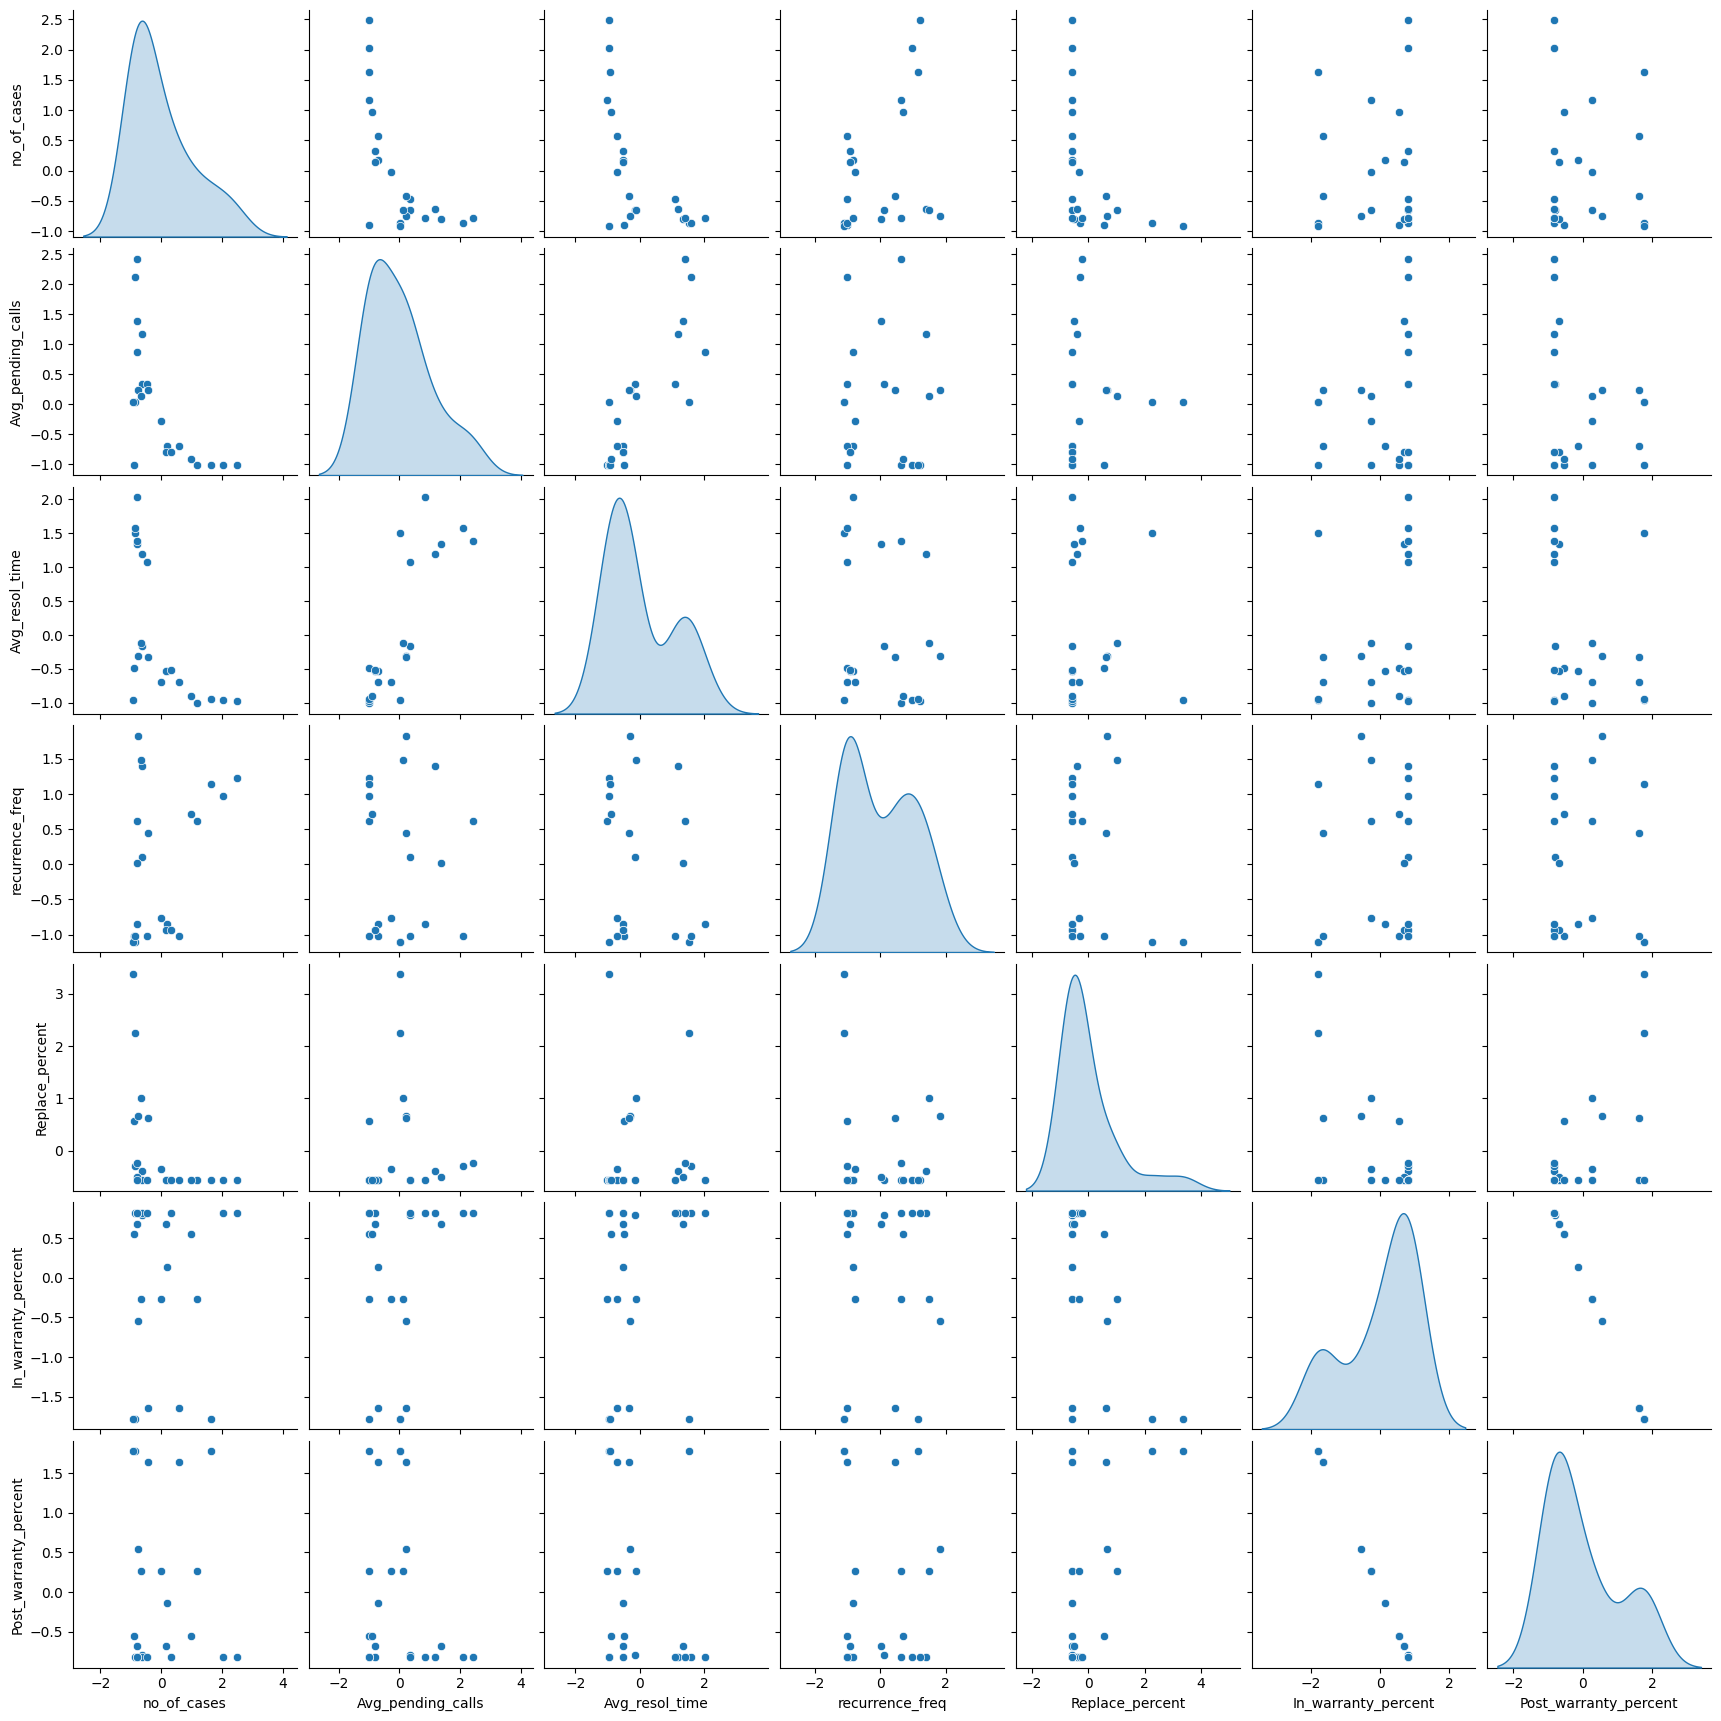

In [4]:
techSuppAttr=tech_supp_df.iloc[:,1:]
techSuppScaled=techSuppAttr.apply(zscore)
sns.pairplot(techSuppScaled,diag_kind='kde')

***Observe the diagonal KDE plot for clusters***

#### ***Group Data into similar clusters using KMeans Clustering based on their attribute***

***First step is to determine the optimal number of groups. We use elbow method to find optimal number of clusters***

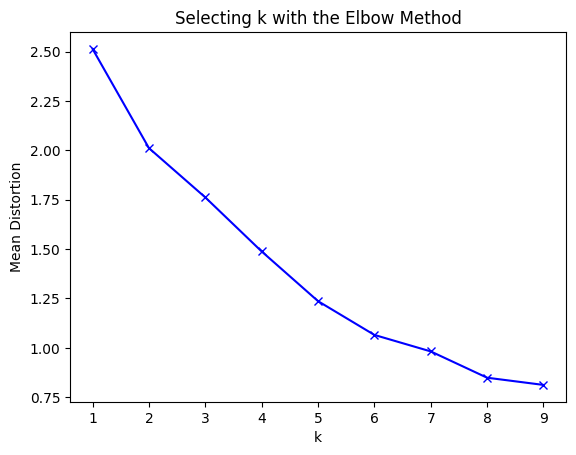

In [5]:
#Finding optimal no. of clusters
from scipy.spatial.distance import cdist # to compute euclidean distance between each point and the cluster centers
clusters=range(1,10)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)  # initializes the model with k clusters
    model.fit(techSuppScaled)   # fit the model using scaled data
    prediction=model.predict(techSuppScaled) # predict the cluster for each data point  
    meanDistortions.append(sum(np.min(cdist(techSuppScaled, model.cluster_centers_, 'euclidean'), axis=1)) / techSuppScaled.shape[0])


plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Mean Distortion')
plt.title('Selecting k with the Elbow Method');


***Though the bend is not coming out clearly as there are many bends, let us look at 3 clusters and 5 clusters***

In [6]:
# Let us first start with K = 3
final_model=KMeans(3)
final_model.fit(techSuppScaled)
prediction=final_model.predict(techSuppScaled)

#Append the prediction 
tech_supp_df["GROUP"] = prediction
techSuppScaled["GROUP"] = prediction
print("Groups Assigned : \n")
tech_supp_df.head()

Groups Assigned : 



,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent,GROUP
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25,1
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95,2
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10,1
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95,2
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1,1


#### ***Analyze the distribution of the data among the two groups***

***(K = 3). One of the most informative visual tool is boxplot.***

In [7]:
techSuppClust = tech_supp_df.iloc[:,1:].groupby(['GROUP'])
techSuppClust.mean()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
GROUP,,,,,,,
0,395.250000,1.025000,7.750000,0.240000,0.000000,87.500000,12.500000
1,76.500000,2.375000,90.250000,0.087500,0.032500,92.833333,7.166667
2,112.142857,1.828571,47.857143,0.165714,0.272857,20.714286,79.285714


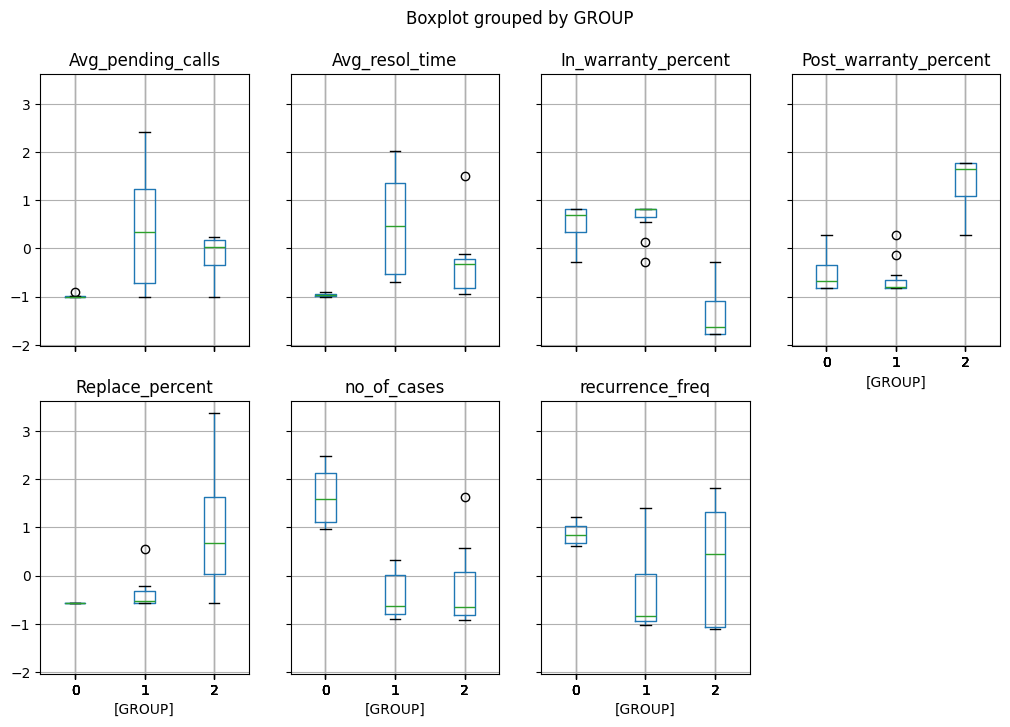

In [8]:
techSuppScaled.boxplot(by='GROUP', layout = (2,4),figsize=(12,8));

***K = 5, the next elbow point***

In [9]:
# Let us first start with K = 5
final_model=KMeans(5)
final_model.fit(techSuppScaled)
prediction=final_model.predict(techSuppScaled)

#Append the prediction 
tech_supp_df["GROUP"] = prediction
techSuppScaled["GROUP"] = prediction
print("Groups Assigned : \n")
tech_supp_df.head()

Groups Assigned : 



,PROBLEM_TYPE,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent,GROUP
0,Temperature control not working,170,1.3,32,0.04,0.0,75,25,2
1,power chord does not tightly fit,12,2.0,150,0.01,0.5,5,95,3
2,Fan swing not working,5,1.0,35,0.02,0.2,90,10,2
3,Main switch does not on,3,2.0,8,0.01,0.7,5,95,3
4,Forgot mobile app password,45,2.3,54,0.15,0.0,99,1,1


In [10]:
techSuppClust = tech_supp_df.iloc[:,1:].groupby(['GROUP'])
techSuppClust.mean()

,no_of_cases,Avg_pending_calls,Avg_resol_time,recurrence_freq,Replace_percent,In_warranty_percent,Post_warranty_percent
GROUP,,,,,,,
0,135.00,1.875000,38.500000,0.280000,0.177500,31.250000,68.750000
1,35.00,3.157143,132.571429,0.125714,0.021429,99.142857,0.857143
2,150.50,1.283333,29.666667,0.031667,0.040000,71.666667,28.333333
3,7.50,2.000000,79.000000,0.010000,0.600000,5.000000,95.000000
4,395.25,1.025000,7.750000,0.240000,0.000000,87.500000,12.500000


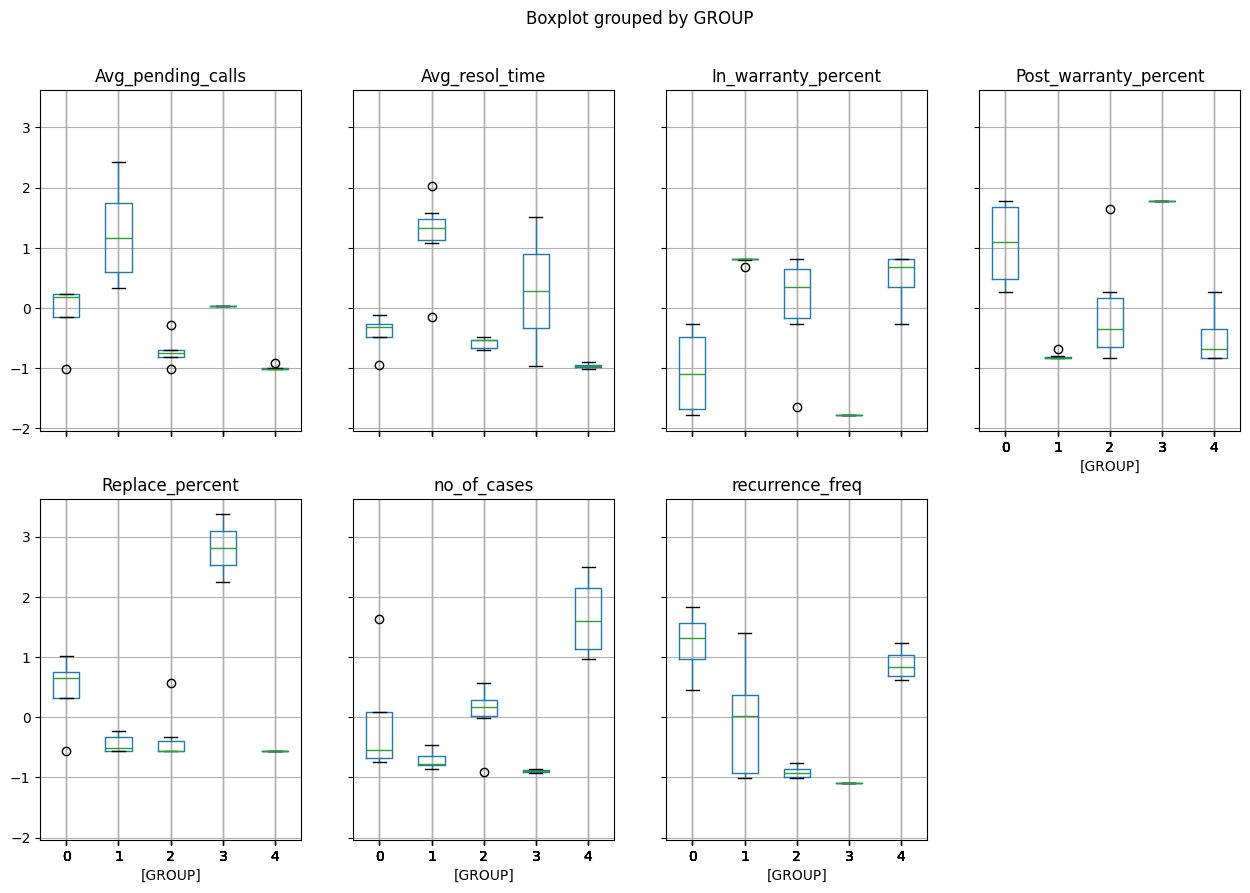

In [11]:
techSuppScaled.boxplot(by='GROUP', layout = (2,4),figsize=(15,10));